In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
import math

In [ ]:
# дубли удалялись при сборе данных по url

df = pd.read_csv("/content/cian_1_4.csv", sep=';')
df.head()

,author,author_type,url,location,deal_type,accommodation_type,floor,floors_count,rooms_count,total_meters,price_per_month,commissions,district,street,house_number,underground,residential_complex
0,Циан х ПИК-Аренда,real_estate_agent,https://www.cian.ru/rent/flat/302091753/,Москва,rent,flat,18,28,1,33.0,75000,0,Можайский,переулок 2-й Петра Алексеева,5,Кунцевская,NaN
1,Циан х ПИК-Аренда,real_estate_agent,https://www.cian.ru/rent/flat/301681276/,Москва,rent,flat,5,19,1,37.4,79000,0,Можайский,Рябиновая,3к3,Рабочий посёлок,NaN
2,Ма-Трёшка,real_estate_agent,https://www.cian.ru/rent/flat/302222519/,Москва,rent,flat,1,25,1,16.0,25000,0,NaN,Бачуринская,13,Коммунарка,NaN
3,Intermark Real Estate,real_estate_agent,https://www.cian.ru/rent/flat/300946117/,Москва,rent,flat,7,8,1,55.0,280000,0,Якиманка,Софийская набережная,34,Новокузнецкая,NaN
4,ЦАН,real_estate_agent,https://www.cian.ru/rent/flat/302372463/,Москва,rent,flat,24,30,1,30.0,100000,0,Тимирязевский,Дмитровский проезд,1,Дмитровская,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5585 entries, 0 to 5584
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   author               5583 non-null   object 
 1   author_type          5583 non-null   object 
 2   url                  5585 non-null   object 
 3   location             5585 non-null   object 
 4   deal_type            5585 non-null   object 
 5   accommodation_type   5585 non-null   object 
 6   floor                5585 non-null   int64  
 7   floors_count         5585 non-null   int64  
 8   rooms_count          5585 non-null   int64  
 9   total_meters         5585 non-null   float64
 10  price_per_month      5585 non-null   int64  
 11  commissions          5585 non-null   int64  
 12  district             5127 non-null   object 
 13  street               5502 non-null   object 
 14  house_number         5570 non-null   object 
 15  underground          5524 non-null   o

In [ ]:
# Посмотрим количество пропусков
df.isna().sum()

author                    2
author_type               2
url                       0
location                  0
deal_type                 0
accommodation_type        0
floor                     0
floors_count              0
rooms_count               0
total_meters              0
price_per_month           0
commissions               0
district                458
street                   83
house_number             15
underground              61
residential_complex    5585
dtype: int64

In [ ]:
# Удалим столбец residential_complex, location, deal_type, accommodation_type (последние 3 не несут никакой важной информации)
df.drop(['residential_complex', 'location', 'deal_type', 'accommodation_type'] , axis=1, inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5585 entries, 0 to 5584
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   author           5583 non-null   object 
 1   author_type      5583 non-null   object 
 2   url              5585 non-null   object 
 3   floor            5585 non-null   int64  
 4   floors_count     5585 non-null   int64  
 5   rooms_count      5585 non-null   int64  
 6   total_meters     5585 non-null   float64
 7   price_per_month  5585 non-null   int64  
 8   commissions      5585 non-null   int64  
 9   district         5127 non-null   object 
 10  street           5502 non-null   object 
 11  house_number     5570 non-null   object 
 12  underground      5524 non-null   object 
dtypes: float64(1), int64(5), object(7)
memory usage: 567.4+ KB


In [ ]:
# Посмотрим, сможем ли заполнить пропуски по district
df['street'].value_counts()

street
1-й Красногвардейский проезд    103
Зеленоград                       52
Ленинский проспект               45
Чапаевский переулок              44
Ленинградский проспект           39
                               ... 
аллея Первой Маевки               1
бульвар Светлый                   1
 Большие Каменщики                1
Каскадная                         1
Басманный переулок                1
Name: count, Length: 1296, dtype: int64

In [ ]:
# Собрали в словарь пары street : district
df1 = df[['street', 'district']]
df1 = df1.dropna().drop_duplicates(subset='street')   # одна и та же улица может относиться к разным районам,
                                                      # в рамках работы мы это не учитываем
dict_df = df1.set_index('street')['district'].to_dict()
dict_df

{'переулок 2-й Петра Алексеева': 'Можайский',
 'Рябиновая ': 'Можайский',
 'Софийская набережная': 'Якиманка',
 'Дмитровский проезд': 'Тимирязевский',
 'Нижегородская ': 'Таганский',
 'Нахимовский проспект': 'Черемушки',
 'Красноярская ': 'Гольяново',
 'Мичуринский проспект': 'Раменки',
 ' Черняховского': 'Аэропорт',
 'Зеленоградская ': 'Головинский',
 'Факультетский переулок': 'Сокол',
 'Дмитровское шоссе': 'Дмитровский',
 'Большой Факельный переулок': 'Таганский',
 ' Трехгорный Вал': 'Пресненский',
 'Грайвороновская ': 'Текстильщики',
 ' Вертолетчиков': 'Некрасовка',
 'Автозаводская ': 'Даниловский',
 'Покровская ': 'Некрасовка',
 'Новгородская ': 'Лианозово',
 'Большая Филевская ': 'Филевский парк',
 ' Василия Ланового': 'Раменки',
 'Кавказский бульвар': 'Царицыно',
 'Селезневская ': 'Тверской',
 'Староалексеевская ': 'Алексеевский',
 ' Ватутина': 'Фили-Давыдково',
 'Ботаническая ': 'Марфино',
 'Балтийская ': 'Сокол',
 'Боровское шоссе': 'Солнцево',
 'проспект Мира': 'Ростокино',
 '

In [ ]:
df_nan = df.loc[df['district'].isna() == True] # Создали df из наблюдений с пропусками по district

In [ ]:
# заполним часть пропусков по district

for elem in df_nan['street']:
    try:
        df['district'].loc[(df['street'] == elem) & (df['district'].isna() == True)] = dict_df[elem]
    except:
        continue

<ipython-input-9-bf9eb92397aa>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['district'].loc[(df['street'] == elem) & (df['district'].isna() == True)] = dict_df[elem]
<ipython-input-9-bf9eb92397aa>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['district'].loc[(df['street'] == elem) & (df['district'].isna() == True)] = dict_df[elem]
<ipython-input-9-bf9eb92397aa>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['district'

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5585 entries, 0 to 5584
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   author           5583 non-null   object 
 1   author_type      5583 non-null   object 
 2   url              5585 non-null   object 
 3   floor            5585 non-null   int64  
 4   floors_count     5585 non-null   int64  
 5   rooms_count      5585 non-null   int64  
 6   total_meters     5585 non-null   float64
 7   price_per_month  5585 non-null   int64  
 8   commissions      5585 non-null   int64  
 9   district         5177 non-null   object 
 10  street           5502 non-null   object 
 11  house_number     5570 non-null   object 
 12  underground      5524 non-null   object 
dtypes: float64(1), int64(5), object(7)
memory usage: 567.4+ KB


In [ ]:
# Описательная статистика

df.describe()

,floor,floors_count,rooms_count,total_meters,price_per_month,commissions
count,5585.000000,5585.000000,5585.000000,5585.000000,5.585000e+03,5585.0
mean,8.606804,16.376007,2.343599,78.871606,1.816263e+06,0.0
std,8.596917,12.974562,1.075219,54.231389,1.238401e+08,0.0
min,1.000000,2.000000,-1.000000,12.000000,1.500000e+04,0.0
25%,3.000000,9.000000,1.000000,40.000000,5.000000e+04,0.0
50%,6.000000,14.000000,2.000000,59.000000,7.000000e+04,0.0
75%,11.000000,19.000000,3.000000,100.000000,2.000000e+05,0.0
max,82.000000,95.000000,5.000000,370.000000,9.255074e+09,0.0


In [ ]:
# Обратили внимание, что по переменной rooms_count минимальное значение равно -1, а по переменной commissions нули
df.drop('commissions', axis=1, inplace=True)
# Выяснили, что по этой переменной есть пропуски, которые обозначаются -1
df.loc[df['rooms_count'] == -1]

,author,author_type,url,floor,floors_count,rooms_count,total_meters,price_per_month,district,street,house_number,underground
1544,Руслан Османов,realtor,https://www.cian.ru/rent/flat/302241063/,3,5,-1,25.5,50000,Хамовники,Зубовская,7,Парк Культуры


In [ ]:
# Так как лишь одно наблюдение содержит пропуск, мы его удалим
df = df.drop([1544])
df.loc[df['rooms_count'] == -1].shape[0] # убедились, что удаление прошло успешно

0

In [ ]:
# Часто встречающиеся значения

df.drop('url',axis=1).mode()

,author,author_type,floor,floors_count,rooms_count,total_meters,price_per_month,district,street,house_number,underground
0,Capital Mars,real_estate_agent,3,9,1,40.0,50000,Пресненский,1-й Красногвардейский проезд,3,Москва-Сити


In [ ]:
df['price_per_m2'] = df['price_per_month'] / df['total_meters'] # Создали новую переменную

In [ ]:
df['author_type'].value_counts()

author_type
real_estate_agent          3639
realtor                    1661
homeowner                   190
unknown                      76
official_representative      16
Name: count, dtype: int64

In [ ]:
df['author'].loc[df['author_type'] == 'real_estate_agent'].value_counts().head(6)

author
Capital Mars             521
MY HOME                  223
Intermark Real Estate    128
ПИК-Аренда               121
Apple Real Estate        118
The IMPERIUM             100
Name: count, dtype: int64

In [ ]:
# Создали дамми-переменные

df['real_estate_agent_dummy'] = 0
df['real_estate_agent_dummy'].loc[df['author_type'] == 'real_estate_agent'] = 1

df['realtor_dummy'] = 0
df['realtor_dummy'].loc[df['author_type'] == 'realtor'] = 1

df['homeowner_dummy'] = 0
df['homeowner_dummy'].loc[df['author_type'] == 'homeowner'] = 1

<ipython-input-18-2b5c644f9320>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['real_estate_agent_dummy'].loc[df['author_type'] == 'real_estate_agent'] = 1
<ipython-input-18-2b5c644f9320>:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['realtor_dummy'].loc[df['author_type'] == 'realtor'] = 1
<ipython-input-18-2b5c644f9320>:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['homeowner_dummy'].loc[df['author_type'] == 'homeown

In [ ]:
df.head()

,author,author_type,url,floor,floors_count,rooms_count,total_meters,price_per_month,district,street,house_number,underground,price_per_m2,real_estate_agent_dummy,realtor_dummy,homeowner_dummy
0,Циан х ПИК-Аренда,real_estate_agent,https://www.cian.ru/rent/flat/302091753/,18,28,1,33.0,75000,Можайский,переулок 2-й Петра Алексеева,5,Кунцевская,2272.727273,1,0,0
1,Циан х ПИК-Аренда,real_estate_agent,https://www.cian.ru/rent/flat/301681276/,5,19,1,37.4,79000,Можайский,Рябиновая,3к3,Рабочий посёлок,2112.299465,1,0,0
2,Ма-Трёшка,real_estate_agent,https://www.cian.ru/rent/flat/302222519/,1,25,1,16.0,25000,NaN,Бачуринская,13,Коммунарка,1562.500000,1,0,0
3,Intermark Real Estate,real_estate_agent,https://www.cian.ru/rent/flat/300946117/,7,8,1,55.0,280000,Якиманка,Софийская набережная,34,Новокузнецкая,5090.909091,1,0,0
4,ЦАН,real_estate_agent,https://www.cian.ru/rent/flat/302372463/,24,30,1,30.0,100000,Тимирязевский,Дмитровский проезд,1,Дмитровская,3333.333333,1,0,0


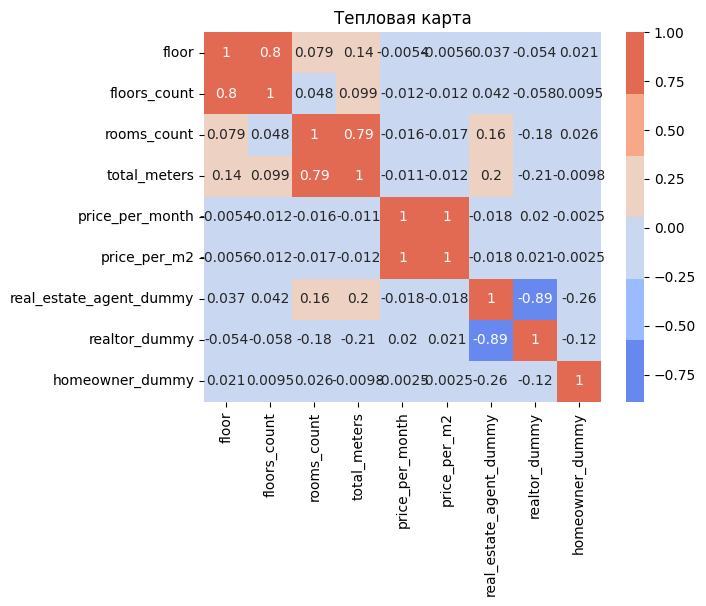

In [ ]:
sns.heatmap(df[['floor', 'floors_count', 'rooms_count', 'total_meters',
                'price_per_month', 'price_per_m2', 'real_estate_agent_dummy', 'realtor_dummy', 'homeowner_dummy']].corr(), annot=True, cmap=sns.color_palette('coolwarm'))
plt.title('Тепловая карта')
plt.show()

array([[<Axes: title={'center': 'floor'}>,
        <Axes: title={'center': 'floors_count'}>,
        <Axes: title={'center': 'rooms_count'}>],
       [<Axes: title={'center': 'total_meters'}>,
        <Axes: title={'center': 'price_per_month'}>,
        <Axes: title={'center': 'price_per_m2'}>],
       [<Axes: title={'center': 'real_estate_agent_dummy'}>,
        <Axes: title={'center': 'realtor_dummy'}>,
        <Axes: title={'center': 'homeowner_dummy'}>]], dtype=object)

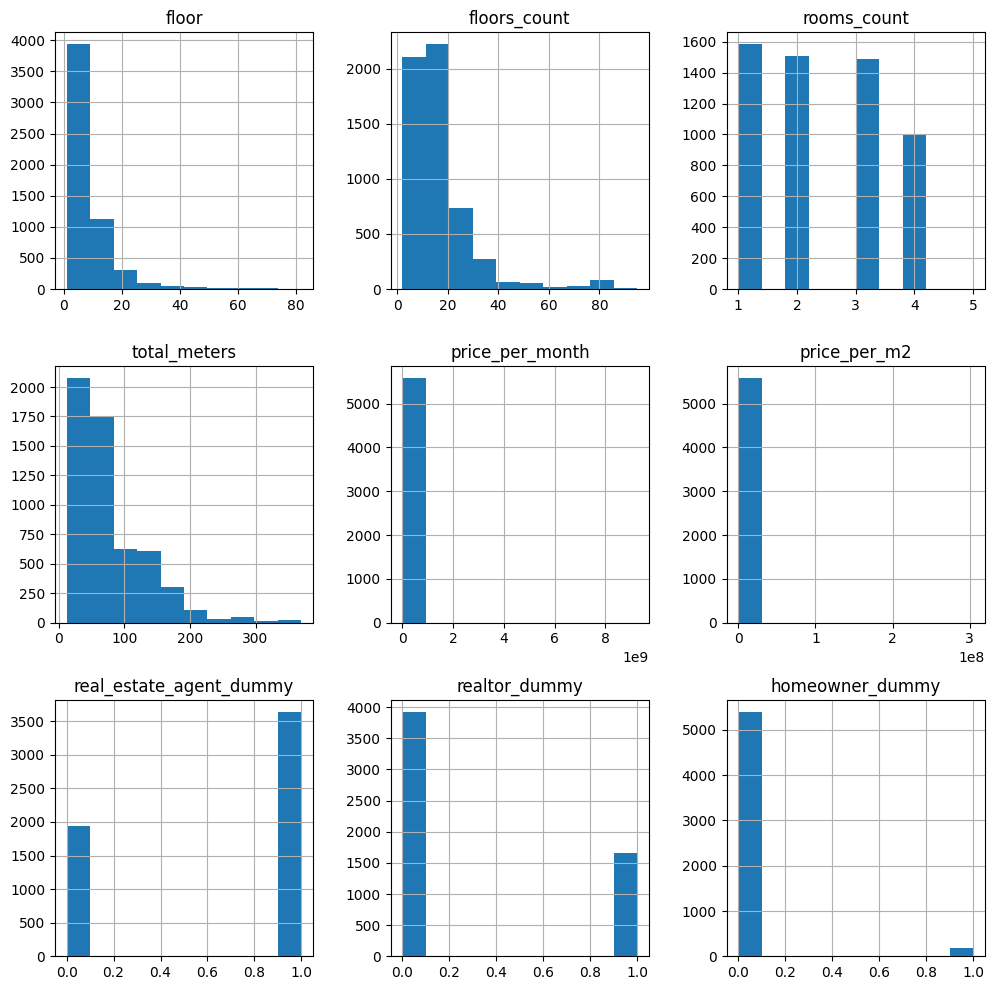

In [ ]:
df.hist(figsize=(12,12))

In [ ]:
ВИдим на графиках цены некоторую странность. Посмотрим максимальные значения.

In [ ]:
df['price_per_m2'].sort_values(ascending=False).head(10)

337     3.044432e+08
1607    1.250000e+04
3080    1.156463e+04
1580    1.111111e+04
1579    1.081081e+04
4561    1.058824e+04
1608    1.052632e+04
5333    1.049383e+04
5332    1.049383e+04
4631    1.049383e+04
Name: price_per_m2, dtype: float64

In [ ]:
df.iloc[337,:]

author                                                    ID 404506
author_type                                                 realtor
url                        https://www.cian.ru/rent/flat/302361426/
floor                                                             5
floors_count                                                      5
rooms_count                                                       1
total_meters                                                   30.4
price_per_month                                          9255073538
district                                                Новогиреево
street                                                    Утренняя 
house_number                                                   16К1
underground                                                  Перово
price_per_m2                                       304443208.486842
real_estate_agent_dummy                                           0
realtor_dummy                                   

In [ ]:
df.drop(337, axis=0, inplace=True)

(array([3.095e+03, 1.815e+03, 4.380e+02, 1.490e+02, 5.100e+01, 1.500e+01,
        5.000e+00, 5.000e+00, 8.000e+00, 2.000e+00]),
 array([  224.21524664,  1451.79372197,  2679.37219731,  3906.95067265,
         5134.52914798,  6362.10762332,  7589.68609865,  8817.26457399,
        10044.84304933, 11272.42152466, 12500.        ]),
 <BarContainer object of 10 artists>)

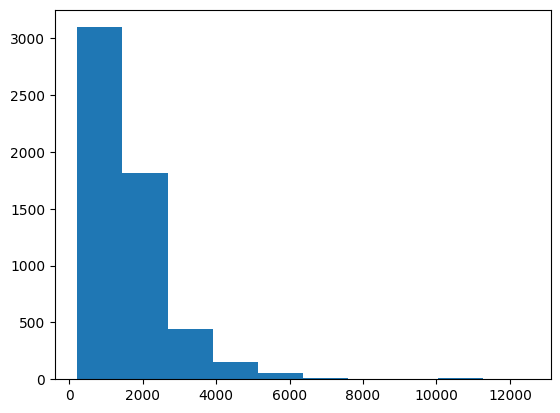

In [ ]:
plt.hist(df['price_per_m2'])


(array([4.313e+03, 8.590e+02, 2.330e+02, 7.800e+01, 3.600e+01, 1.900e+01,
        5.000e+00, 8.000e+00, 3.000e+01, 2.000e+00]),
 array([  15000.,  213500.,  412000.,  610500.,  809000., 1007500.,
        1206000., 1404500., 1603000., 1801500., 2000000.]),
 <BarContainer object of 10 artists>)

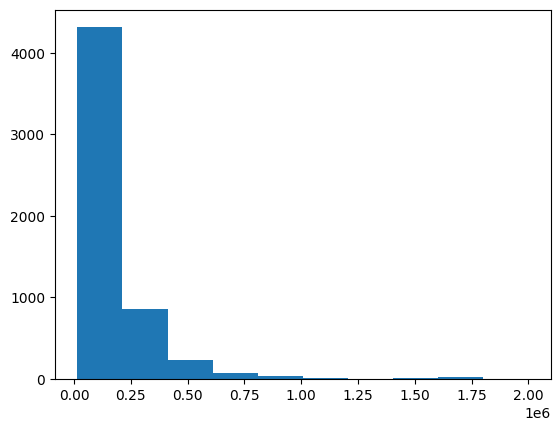

In [ ]:
plt.hist(df['price_per_month'])

array([[<Axes: title={'center': 'floor'}>,
        <Axes: title={'center': 'floors_count'}>,
        <Axes: title={'center': 'rooms_count'}>],
       [<Axes: title={'center': 'total_meters'}>,
        <Axes: title={'center': 'price_per_month'}>,
        <Axes: title={'center': 'price_per_m2'}>],
       [<Axes: title={'center': 'real_estate_agent_dummy'}>,
        <Axes: title={'center': 'realtor_dummy'}>,
        <Axes: title={'center': 'homeowner_dummy'}>]], dtype=object)

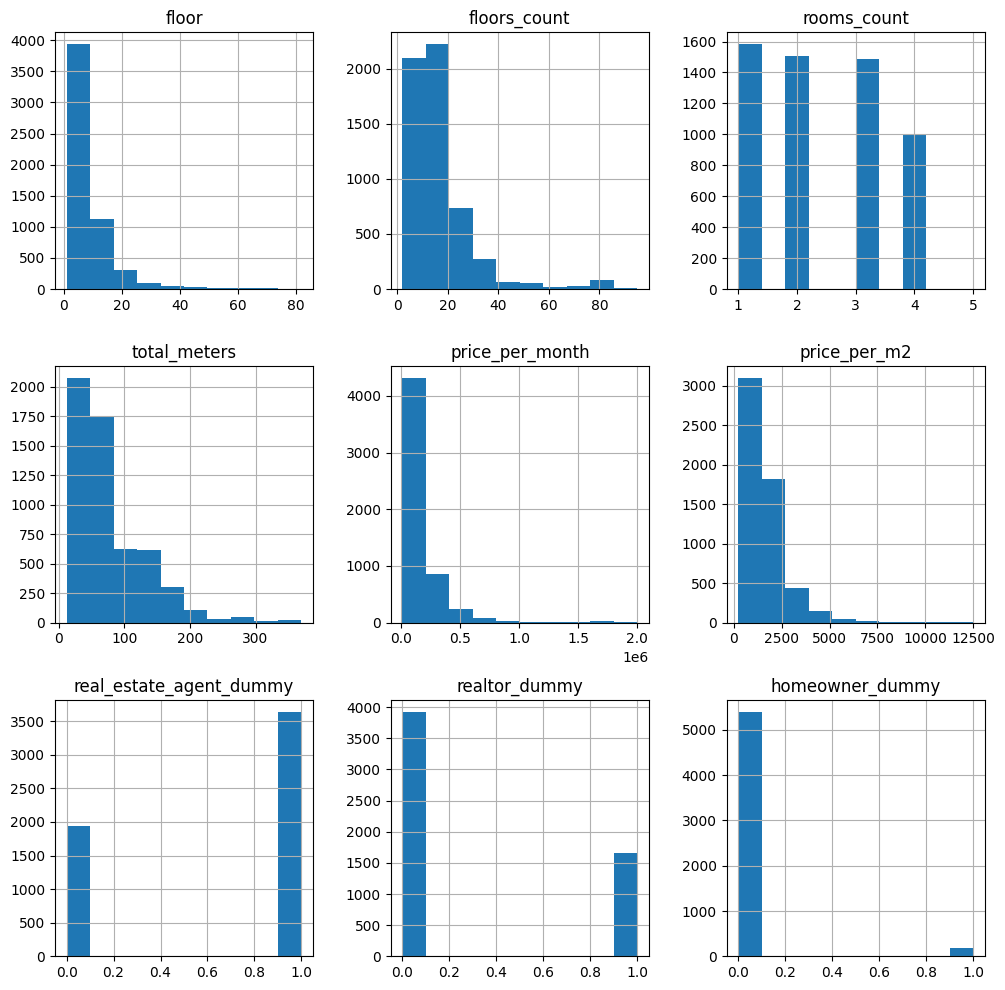

In [ ]:
df.hist(figsize=(12,12))

Text(0.5, 1.0, 'ТОП-10 станций метро по количеству объявлений')

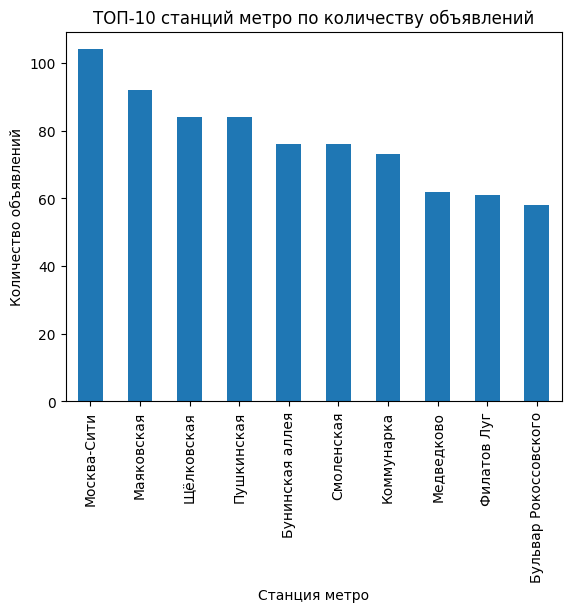

In [ ]:
df['underground'].value_counts().head(10).plot(kind='bar')
plt.xlabel('Станция метро')
plt.ylabel('Количество объявлений')
plt.title("ТОП-10 станций метро по количеству объявлений")

Text(0.5, 1.0, 'ТОП-10 районов Москвы по количеству объявлений')

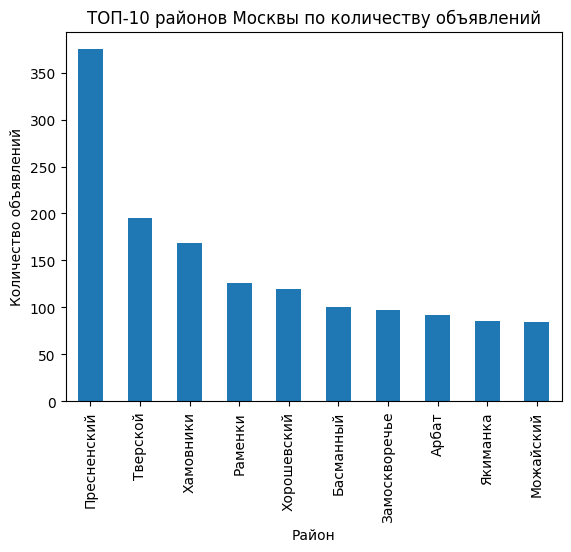

In [ ]:
df['district'].value_counts().head(10).plot(kind='bar')
plt.xlabel('Район')
plt.ylabel('Количество объявлений')
plt.title("ТОП-10 районов Москвы по количеству объявлений")

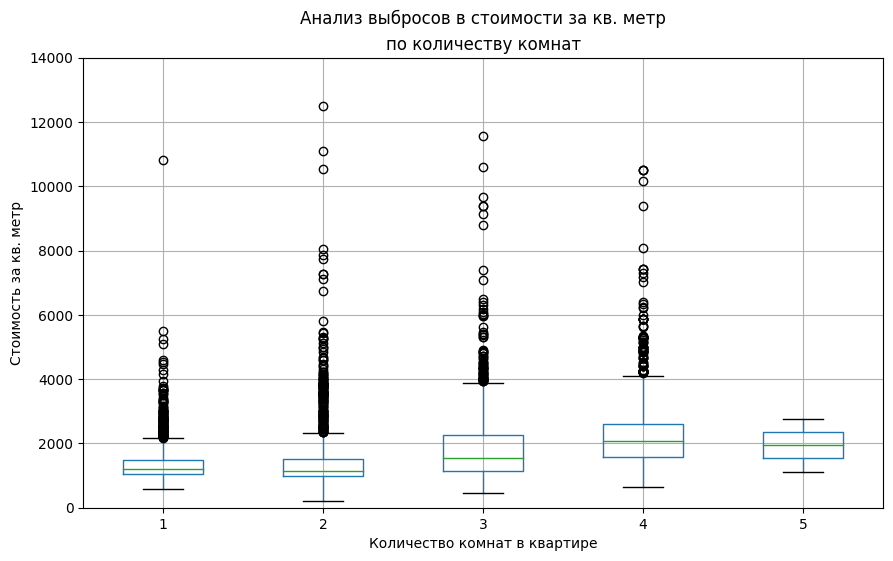

In [ ]:
df.boxplot(column='price_per_m2', by = 'rooms_count', figsize=(10,6))
plt.ylim(0,14000)  # Если не устанавливать ограничение, то боксплоты будут неинформативны
plt.suptitle('Анализ выбросов в стоимости за кв. метр')
plt.title('по количеству комнат')
plt.ylabel('Стоимость за кв. метр')
plt.xlabel('Количество комнат в квартире')
plt.show()

In [ ]:
df.loc[(df['rooms_count'] == 1)].drop('url', axis=1).mode()

,author,author_type,floor,floors_count,rooms_count,total_meters,price_per_month,district,street,house_number,underground,price_per_m2,real_estate_agent_dummy,realtor_dummy,homeowner_dummy
0,Capital Mars,real_estate_agent,5,17,1,40.0,40000,Южное Бутово,Зеленоград,3,Бунинская аллея,1000.0,1,0,0


In [ ]:
df.loc[(df['rooms_count'] == 2)].drop('url', axis=1).mode()

,author,author_type,floor,floors_count,rooms_count,total_meters,price_per_month,district,street,house_number,underground,price_per_m2,real_estate_agent_dummy,realtor_dummy,homeowner_dummy
0,Capital Mars,real_estate_agent,2.0,9.0,2.0,45.0,60000.0,Пресненский,1-й Красногвардейский проезд,2,Москва-Сити,1000.0,1.0,0.0,0.0
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.loc[(df['rooms_count'] == 3)].drop('url', axis=1).mode()

,author,author_type,floor,floors_count,rooms_count,total_meters,price_per_month,district,street,house_number,underground,price_per_m2,real_estate_agent_dummy,realtor_dummy,homeowner_dummy
0,Capital Mars,real_estate_agent,3,9,3,80.0,250000,Пресненский,1-й Красногвардейский проезд,2,Москва-Сити,1000.0,1,0,0


In [ ]:
df.loc[(df['rooms_count'] == 4)].drop('url', axis=1).mode()

,author,author_type,floor,floors_count,rooms_count,total_meters,price_per_month,district,street,house_number,underground,price_per_m2,real_estate_agent_dummy,realtor_dummy,homeowner_dummy
0,Intermark Real Estate,real_estate_agent,5,7,4,150.0,350000,Пресненский,Чапаевский переулок,3,Пушкинская,1666.666667,1,0,0


In [ ]:
df = df[['price_per_m2', 'floor', 'rooms_count', 'floors_count', 'district','real_estate_agent_dummy', 'total_meters', 'homeowner_dummy']].dropna()

In [ ]:
# Преобразуем переменную district в числовую категориальную
df['dist_cat'] = pd.Categorical(df['district'])
df['dist_cat'] = df['dist_cat'].cat.codes

# Логарифмируем зависимую переменную price_per_m2
log_price_per_m2 = np.log(df['price_per_m2'])

In [ ]:
# Регрессия
x = df[['floor', 'rooms_count', 'floors_count', 'real_estate_agent_dummy',
        'dist_cat', 'total_meters', 'homeowner_dummy']]

# Создаем модель линейной регрессии
model = sm.OLS(log_price_per_m2, x)
results = model.fit()

# Печатаем статистику модели
print(results.summary())

                                 OLS Regression Results                                
Dep. Variable:           price_per_m2   R-squared (uncentered):                   0.923
Model:                            OLS   Adj. R-squared (uncentered):              0.923
Method:                 Least Squares   F-statistic:                              8884.
Date:                Wed, 29 May 2024   Prob (F-statistic):                        0.00
Time:                        16:03:31   Log-Likelihood:                         -11033.
No. Observations:                5175   AIC:                                  2.208e+04
Df Residuals:                    5168   BIC:                                  2.213e+04
Df Model:                           7                                                  
Covariance Type:            nonrobust                                                  
                              coef    std err          t      P>|t|      [0.025      0.975]
----------------------------

Так как в модель не включена константа, то интерпретировать R^2 как меру объясняющей способности модели некорректно, поэтому модель в данном случае выступает инструментом оценки влияния факторов на целевую переменную.